In [9]:
#XGB classifier on same features as NN, to compare performance and training time.
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc
import sys
sys.path.append('..')  # goes up from NN/ to I_Project/
from Modules.Utils import fast_preprocess_data  
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.metrics import f1_score



In [2]:
x_train, x_test, y_train, y_test = fast_preprocess_data('/Users/prometheus/Documents/Python/I_Project/Data/AppML_InitialProject_train.h5', 'p_Truth_isElectron', test_size=0.2)

No missing values detected in the dataset.
Dropped 44 highly correlated features


In [3]:
#fit the model
parameters = {
    'n_estimators': 10000,
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'reg_lambda': 1,
    'eval_metric': 'logloss',
    'early_stopping_rounds': 10
}

model = XGBClassifier(**parameters)
model.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_test, y_test)])

print("Best iteration:", model.get_booster().best_iteration)

[0]	validation_0-logloss:0.45275	validation_1-logloss:0.45251
[1]	validation_0-logloss:0.41162	validation_1-logloss:0.41169
[2]	validation_0-logloss:0.38051	validation_1-logloss:0.38084
[3]	validation_0-logloss:0.35592	validation_1-logloss:0.35650
[4]	validation_0-logloss:0.33481	validation_1-logloss:0.33540
[5]	validation_0-logloss:0.31735	validation_1-logloss:0.31797
[6]	validation_0-logloss:0.30201	validation_1-logloss:0.30267
[7]	validation_0-logloss:0.28964	validation_1-logloss:0.29043
[8]	validation_0-logloss:0.27794	validation_1-logloss:0.27882
[9]	validation_0-logloss:0.26816	validation_1-logloss:0.26918
[10]	validation_0-logloss:0.25919	validation_1-logloss:0.26028
[11]	validation_0-logloss:0.25165	validation_1-logloss:0.25284
[12]	validation_0-logloss:0.24478	validation_1-logloss:0.24608
[13]	validation_0-logloss:0.23860	validation_1-logloss:0.23995
[14]	validation_0-logloss:0.23296	validation_1-logloss:0.23435
[15]	validation_0-logloss:0.22805	validation_1-logloss:0.22946
[1

In [4]:
#evaluate the model
y_pred = model.predict(x_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     28458
           1       0.95      0.77      0.85      7542

    accuracy                           0.94     36000
   macro avg       0.94      0.88      0.91     36000
weighted avg       0.94      0.94      0.94     36000

Confusion Matrix:
[[28131   327]
 [ 1762  5780]]
Accuracy Score: 0.9419722222222222


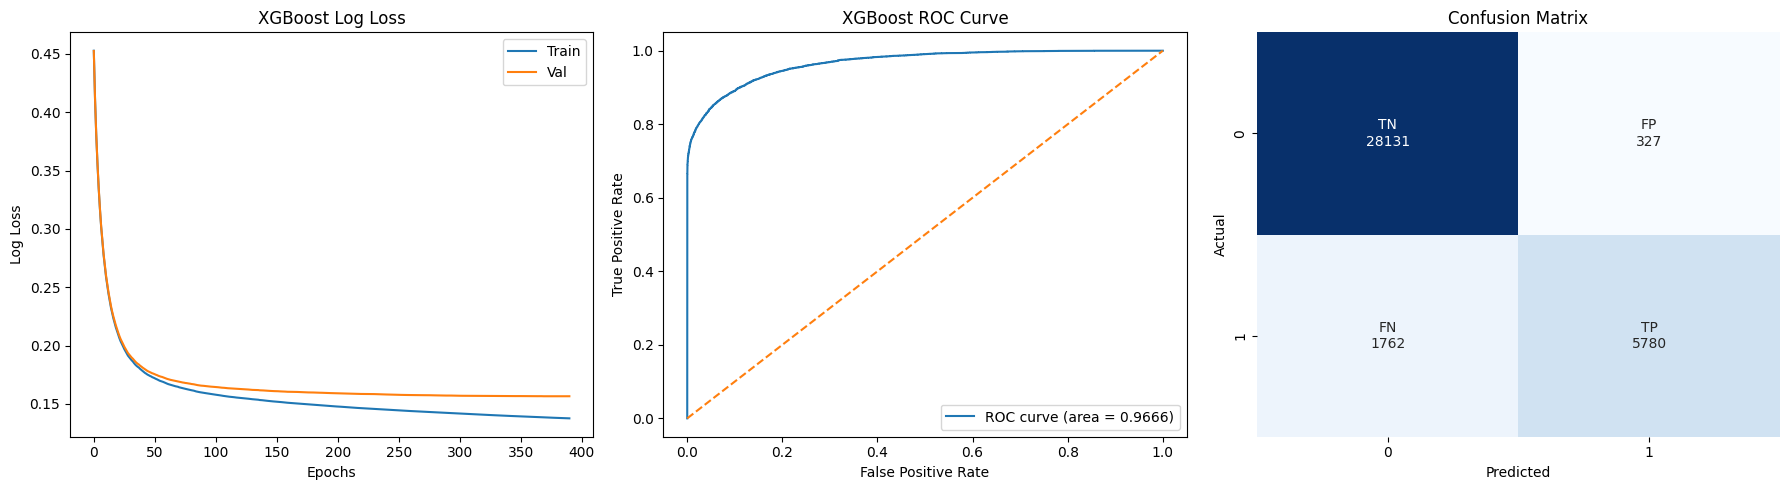

In [5]:
#plot training loss, roc curve and confusion matrix with tp fp tn fn labels
results = model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
plt.plot(x_axis, results['validation_1']['logloss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss')
plt.legend()

y_prob = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend()

cm = confusion_matrix(y_test, y_pred)
labels = [['TN', 'FP'], ['FN', 'TP']]
annot = [[f"{l}\n{v}" for l, v in zip(row_l, row_v)] for row_l, row_v in zip(labels, cm)]
plt.subplot(1, 3, 3)
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()


In [11]:
#use optuna to optimize hyperparameters, with early stopping and pruning
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0),
        'eval_metric': 'logloss',
        'early_stopping_rounds': 10
    }
    
    model = XGBClassifier(**params)
    model.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_test, y_test)], verbose=False)
    
    y_pred = model.predict(x_test)
    return f1_score(y_test, y_pred)

#evaluate the best hyperparameters found by optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=500, n_jobs=-1)

print("Best trial:")
trial = study.best_trial
print("  Value: ", trial.value)
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2026-04-30 16:22:24,701] A new study created in memory with name: no-name-100de125-508c-4c2f-8f3d-77c2d750d95b
[I 2026-04-30 16:22:27,524] Trial 6 finished with value: 0.8459618208516887 and parameters: {'n_estimators': 912, 'max_depth': 8, 'learning_rate': 0.15910949592910292, 'subsample': 0.9702726485601686, 'reg_lambda': 2.9744333825625913}. Best is trial 6 with value: 0.8459618208516887.
[I 2026-04-30 16:22:28,114] Trial 4 finished with value: 0.8467410452143277 and parameters: {'n_estimators': 455, 'max_depth': 10, 'learning_rate': 0.12754497458492098, 'subsample': 0.8052860137912179, 'reg_lambda': 4.594196853432841}. Best is trial 4 with value: 0.8467410452143277.
[I 2026-04-30 16:22:28,514] Trial 2 finished with value: 0.8463513017968464 and parameters: {'n_estimators': 280, 'max_depth': 8, 'learning_rate': 0.12133932806296638, 'subsample': 0.6549047621646157, 'reg_lambda': 8.53702098949932}. Best is trial 4 with value: 0.8467410452143277.
[I 2026-04-30 16:22:28,824] Trial 7 

Best trial:
  Value:  0.8509357798165138
  Params: 
    n_estimators: 932
    max_depth: 8
    learning_rate: 0.017026551752134078
    subsample: 0.6011659792891848
    reg_lambda: 8.56001785052128


In [12]:
#use best hyperparameters to fit the model and evaluate again
best_params = trial.params
best_params['eval_metric'] = 'logloss'
best_params['early_stopping_rounds'] = 10
model = XGBClassifier(**best_params)
model.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_test, y_test)], verbose=False)

print("Best iteration:", model.get_booster().best_iteration)
#evaluate the model
y_pred = model.predict(x_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Best iteration: 772
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     28458
           1       0.95      0.77      0.85      7542

    accuracy                           0.94     36000
   macro avg       0.95      0.88      0.91     36000
weighted avg       0.94      0.94      0.94     36000

Confusion Matrix:
[[28172   286]
 [ 1745  5797]]
Accuracy Score: 0.9435833333333333


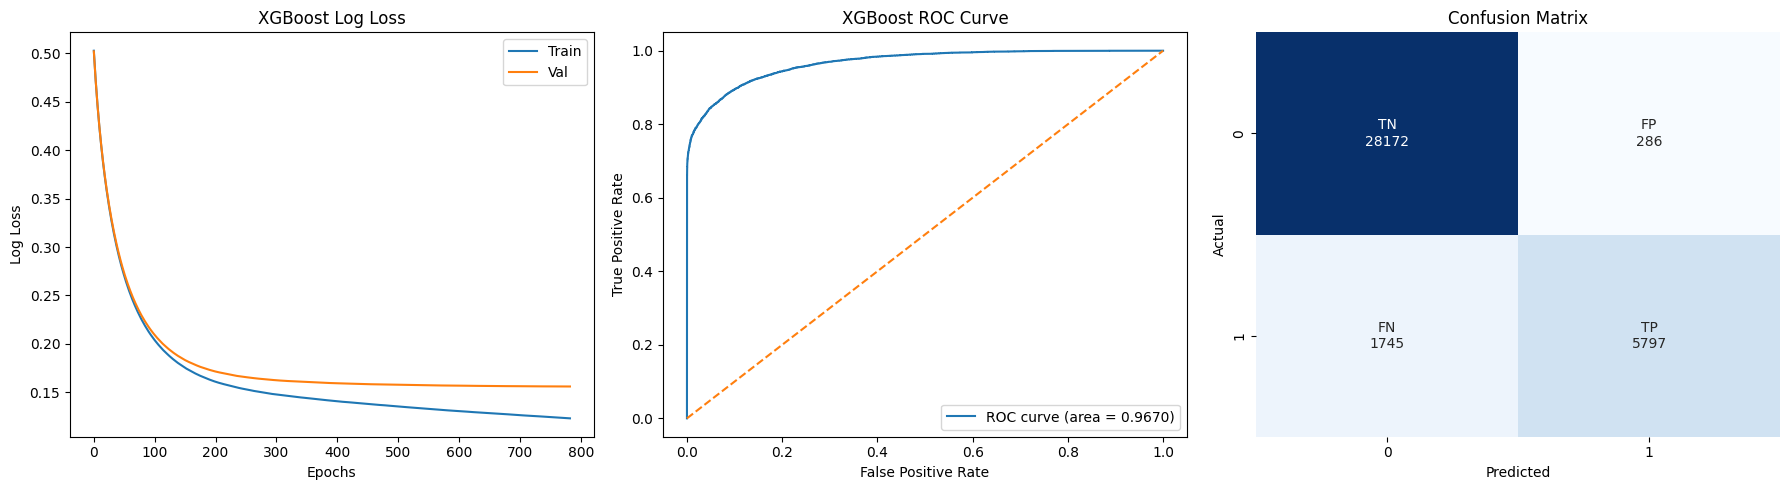

In [13]:
#plot training loss, roc curve and confusion matrix with tp fp tn fn labels
results = model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
plt.plot(x_axis, results['validation_1']['logloss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss')
plt.legend()

y_prob = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend()

cm = confusion_matrix(y_test, y_pred)
labels = [['TN', 'FP'], ['FN', 'TP']]
annot = [[f"{l}\n{v}" for l, v in zip(row_l, row_v)] for row_l, row_v in zip(labels, cm)]
plt.subplot(1, 3, 3)
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()
